In [52]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("../data/taxi_trip_pricing.csv")

df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [3]:
df = df.dropna(subset=["Trip_Price"])

In [4]:
X = df.drop(columns=["Trip_Price"])
y = df["Trip_Price"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
X_train.shape

(760, 10)

In [7]:
X_test.shape

(191, 10)

In [8]:
numerical_features = X_train.select_dtypes(include="number").columns.tolist()

categorical_features = X_train.select_dtypes(include="str").columns.tolist()

print("Numerical Features: ", numerical_features)
print("Categorical Features: ", categorical_features)

Numerical Features:  ['Trip_Distance_km', 'Passenger_Count', 'Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration_Minutes']
Categorical Features:  ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']


In [9]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [10]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [11]:
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [17]:
# We are testing firstly that can we solve this problem using only one feature that is Trip Distance
slr_feature = ["Trip_Distance_km"]

X_train_slr = X_train[slr_feature]
X_test_slr = X_test[slr_feature]

In [18]:
X_train_slr.head()

,Trip_Distance_km
340,25.09
571,39.40
584,NaN
115,43.70
81,31.54


In [19]:
slr_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [20]:
slr_pipeline = Pipeline([
    ("preprocessor", slr_preprocessor),
    ("model", LinearRegression())
])

In [21]:
slr_pipeline.fit(X_train_slr, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](1,)",['Trip_Distance_km']
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_

In [23]:
slr_predictions = slr_pipeline.predict(X_test_slr)

slr_predictions[:10]

array([58.01797287, 90.79914419, 26.39496888, 25.48857705, 58.57187899,
       42.74359196, 25.65642739, 46.06702868, 30.5576573 , 34.09929947])

In [24]:
def evaluate_regression_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [25]:
slr_metrics = evaluate_regression_model(y_test, slr_predictions)

slr_metrics

{'MAE': 16.92065167735525,
 'MSE': 572.4733693774618,
 'RMSE': np.float64(23.92641572357761),
 'R2': 0.755078913222591}

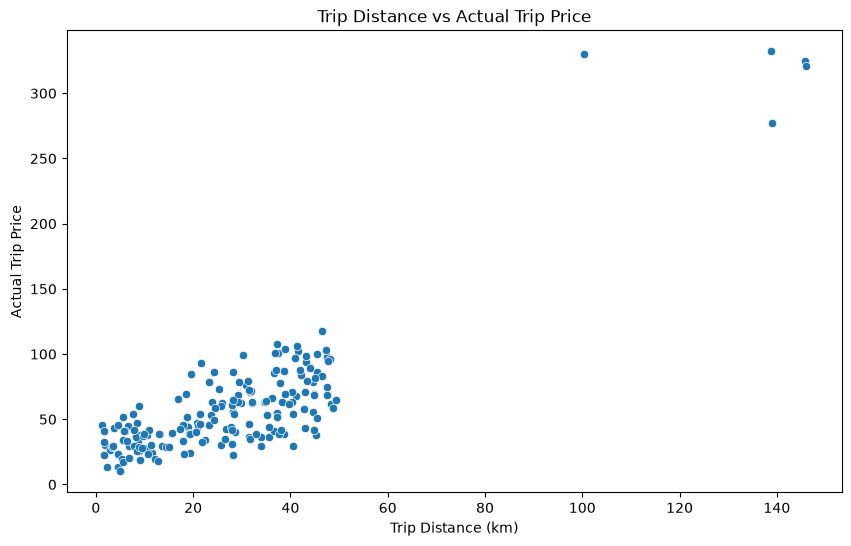

In [30]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=X_test_slr["Trip_Distance_km"],
    y=y_test
)

plt.xlabel("Trip Distance (km)")
plt.ylabel("Actual Trip Price")
plt.title("Trip Distance vs Actual Trip Price")

plt.show()

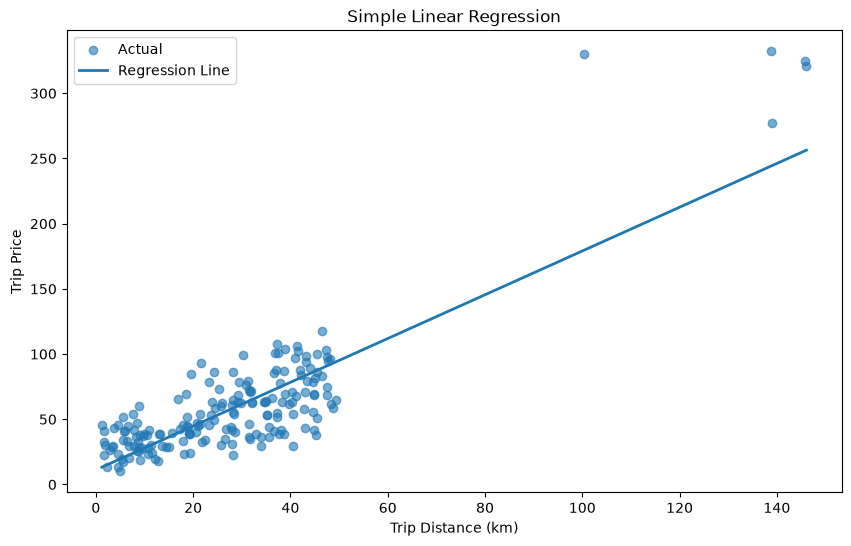

In [32]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_test_slr["Trip_Distance_km"],
    y_test,
    alpha=0.6,
    label="Actual"
)

# Sort values so the regression line is drawn properly
sort_idx = np.argsort(
    X_test_slr["Trip_Distance_km"].values
)

plt.plot(
    X_test_slr["Trip_Distance_km"].values[sort_idx],
    slr_predictions[sort_idx],
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Trip Distance (km)")
plt.ylabel("Trip Price")
plt.title("Simple Linear Regression")
plt.legend()

plt.show()

In [33]:
slr_model = slr_pipeline.named_steps["model"]

In [35]:
print("Intercept: ", slr_model.intercept_)
print("Coefficient: ", slr_model.coef_[0])

Intercept:  56.03263214474346
Coefficient:  31.661480133046314


In [37]:
mlr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [38]:
mlr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Trip_Distance_km','Time_of_Day','Day_of_Week',...,'Per_Km_Rate', 'Per_Minute_Rate','Trip_Duration_Minutes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically 

In [39]:
mlr_predictions = mlr_pipeline.predict(X_test)

mlr_predictions[:10]

array([ 44.65099721, 106.87133456,   0.86652274,  45.25632222,
        67.81921425,  43.34097904,  26.54972901,  43.91724373,
        23.06025334,  26.68054825])

In [40]:
mlr_metrics = evaluate_regression_model(y_test, mlr_predictions)

mlr_metrics

{'MAE': 9.930364474930709,
 'MSE': 289.984447089814,
 'RMSE': np.float64(17.028929710636955),
 'R2': 0.8759360526988045}

In [42]:
baseline_model = DummyRegressor(
    strategy="mean"
)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_test)

baseline_metrics = evaluate_regression_model(y_test, baseline_predictions)

In [43]:
results = pd.DataFrame([
    { "Model": "Mean Baseline", **baseline_metrics },
    { "Model": "Simple Linear Regression", **slr_metrics },
    { "Model": "Multiple Linear Regression", **mlr_metrics },
])

In [44]:
results

,Model,MAE,MSE,RMSE,R2
0,Mean Baseline,26.608843,2354.960686,48.527937,-0.007522
1,Simple Linear Regression,16.920652,572.473369,23.926416,0.755079
2,Multiple Linear Regression,9.930364,289.984447,17.028930,0.875936


In [ ]:
mlr_model = mlr_pipeline.named_steps["model"]

In [46]:
feature_names = mlr_pipeline.named_steps["preprocessor"].get_feature_names_out()

In [47]:
coefficients = mlr_model.coef_

In [48]:
coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [50]:
coefficient_df = coefficient_df.sort_values(by="Coefficient", ascending=False)

coefficient_df

,Feature,Coefficient
0,num__Trip_Distance_km,32.222543
3,num__Per_Km_Rate,10.264807
5,num__Trip_Duration_Minutes,9.661750
4,num__Per_Minute_Rate,6.134999
17,cat__Weather_Snow,1.814397
12,cat__Traffic_Conditions_High,1.120402
8,cat__Time_of_Day_Morning,1.089418
7,cat__Time_of_Day_Evening,0.466477
6,cat__Time_of_Day_Afternoon,0.370120
10,cat__Day_of_Week_Weekday,0.007595


In [51]:
mlr_model.intercept_

np.float64(56.36913351777386)

In [53]:
joblib.dump(
    mlr_pipeline,
    "../models/linear_regression_pipeline.pkl"
)

['../models/linear_regression_pipeline.pkl']

## Linear Regression Results

Three approaches were evaluated:

1. Mean Baseline
2. Simple Linear Regression using `Trip_Distance_km`
3. Multiple Linear Regression using numerical and categorical features

Simple Linear Regression establishes how much predictive information can be obtained from trip distance alone.

Multiple Linear Regression incorporates additional trip characteristics and allows us to evaluate whether these additional features improve predictive performance.

The models were evaluated using MAE, MSE, RMSE, and R² on the same held-out test set.

### Key Findings

- The baseline provides a reference point for model performance.
- SLR demonstrates the predictive relationship between trip distance and trip price.
- MLR uses additional trip characteristics.
- The final model comparison is based on the test-set evaluation metrics.